In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
from sklearn.datasets import make_classification
X,y = make_classification(n_features=5, n_redundant=0, n_informative=5,n_clusters_per_class=1)

In [3]:
df = pd.DataFrame(X, columns=['col1','col2','col3','col4','col5'])
df['target'] = y
df

,col1,col2,col3,col4,col5,target
0,-0.310067,-0.019655,1.443667,-0.389374,1.025242,1
1,-0.887441,-0.531451,-0.627011,0.959740,0.696390,0
2,-3.775806,-1.364925,-0.386868,3.768091,-0.339912,0
3,-2.287863,-0.575837,-1.114979,1.896152,0.790460,0
4,0.924946,-0.270042,2.326693,-2.353531,-0.745989,1
...,...,...,...,...,...,...
95,0.018315,1.099070,4.206578,-0.327919,2.080370,1
96,-1.125571,-2.299931,1.089800,-1.009185,2.000831,1
97,-1.457710,-4.965096,-0.035608,-4.086645,2.288881,1
98,-1.596421,-2.211565,-1.228426,-0.995780,-0.074260,1


In [4]:
def row_sampling(df, row_sampling_ratio):
    return df.sample(int(row_sampling_ratio * df.shape[0]), replace=False)

In [5]:
def col_sampling(df, col_sampling_ratio):
    temp = df.iloc[:,:-1].sample(int(col_sampling_ratio * df.shape[1]),axis=1, replace=False)
    temp['target'] = df.iloc[:,-1]
    return temp

In [6]:
def combined_sampling(df,row_sampling_ratio, col_sampling_ratio):
    temp = df.sample(int(row_sampling_ratio * df.shape[0]),axis=0, replace=False)
    temp2 = temp.iloc[:,:-1].sample(int(col_sampling_ratio * df.shape[1]),axis=1, replace=False)
    temp2['target'] = temp.iloc[:,-1]
    return temp2

In [7]:
import warnings
warnings.filterwarnings("ignore")

In [8]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [9]:
df_train = pd.concat([pd.DataFrame(X_train,columns=['col1','col2','col3','col4','col5']),pd.DataFrame(y_train,columns=['target'])], axis=1)
df_train

,col1,col2,col3,col4,col5,target
0,-2.837803,-1.179631,0.315691,3.006489,-0.705415,0
1,-0.443393,-0.209516,-1.180519,-0.072694,1.493100,0
2,-2.116570,-2.057723,-2.474669,2.544966,0.771635,0
3,-4.365876,-0.844284,0.542928,2.303949,3.056340,1
4,-0.858999,-1.247981,-1.917330,-2.053579,1.102449,1
...,...,...,...,...,...,...
75,-0.793205,-1.094723,-0.073156,1.190878,0.862699,0
76,0.210269,0.765790,2.880967,0.102222,1.677759,1
77,-2.797061,-2.077315,-1.712714,2.926372,0.289088,0
78,0.705869,-0.413923,2.356988,-0.317166,-0.150782,1


In [10]:
df_test = pd.concat([pd.DataFrame(X_test,columns=['col1','col2','col3','col4','col5']),pd.DataFrame(y_test,columns=['target'])], axis=1)

In [11]:
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.metrics import accuracy_score


def plot_decision_tree(X_train, y_train, features_list=None):
    if features_list is None:
        features_list = X_train.columns.tolist()
    model = DecisionTreeClassifier()
    
    model.fit(X_train, y_train)
    
    indices = [X_train.columns.get_loc(col) for col in features_list]
    X_test_sub = X_test[:, indices]
    y_pred = model.predict(X_test_sub)
    print("Accuracy:",accuracy_score(y_test, y_pred))
    plt.figure(figsize=(16,12))
    plot_tree(
        model,
        feature_names=features_list,
        class_names=[str(int(cls)) for cls in np.unique(y_train)],
        filled=True,
        rounded=True,
        fontsize=10
    )
    return model

In [12]:
def split_X_y(df):
    return df.iloc[:,:-1], df.iloc[:,-1]

# 1. Row Sampling

#### Tree1 

Accuracy: 0.75


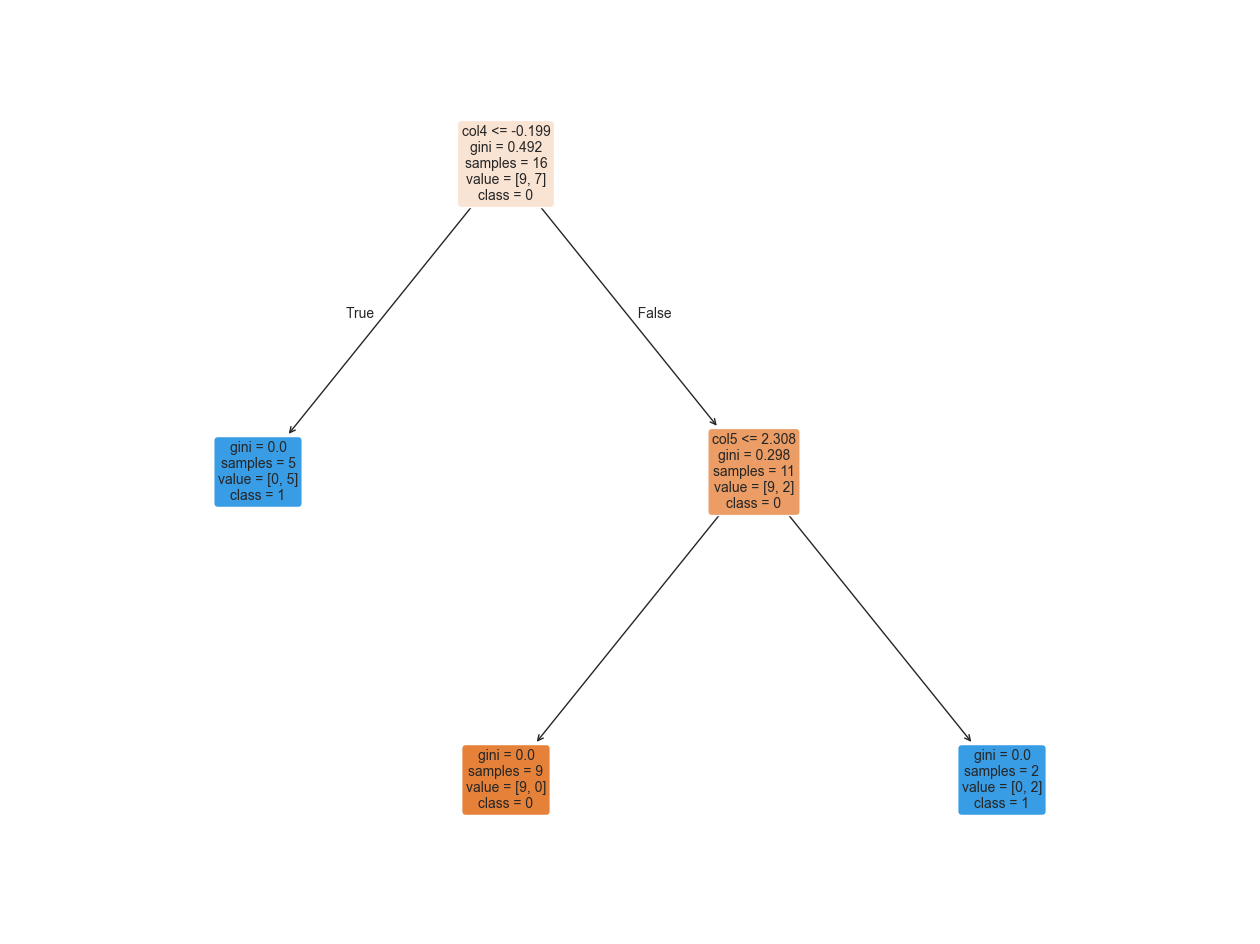

In [13]:
df_row_sample1 = row_sampling(df_train,row_sampling_ratio=0.2)

X_train1, y_train1 = split_X_y(df_row_sample1)
dt1 = plot_decision_tree(X_train1, y_train1)

#### Tree2

Accuracy: 0.7


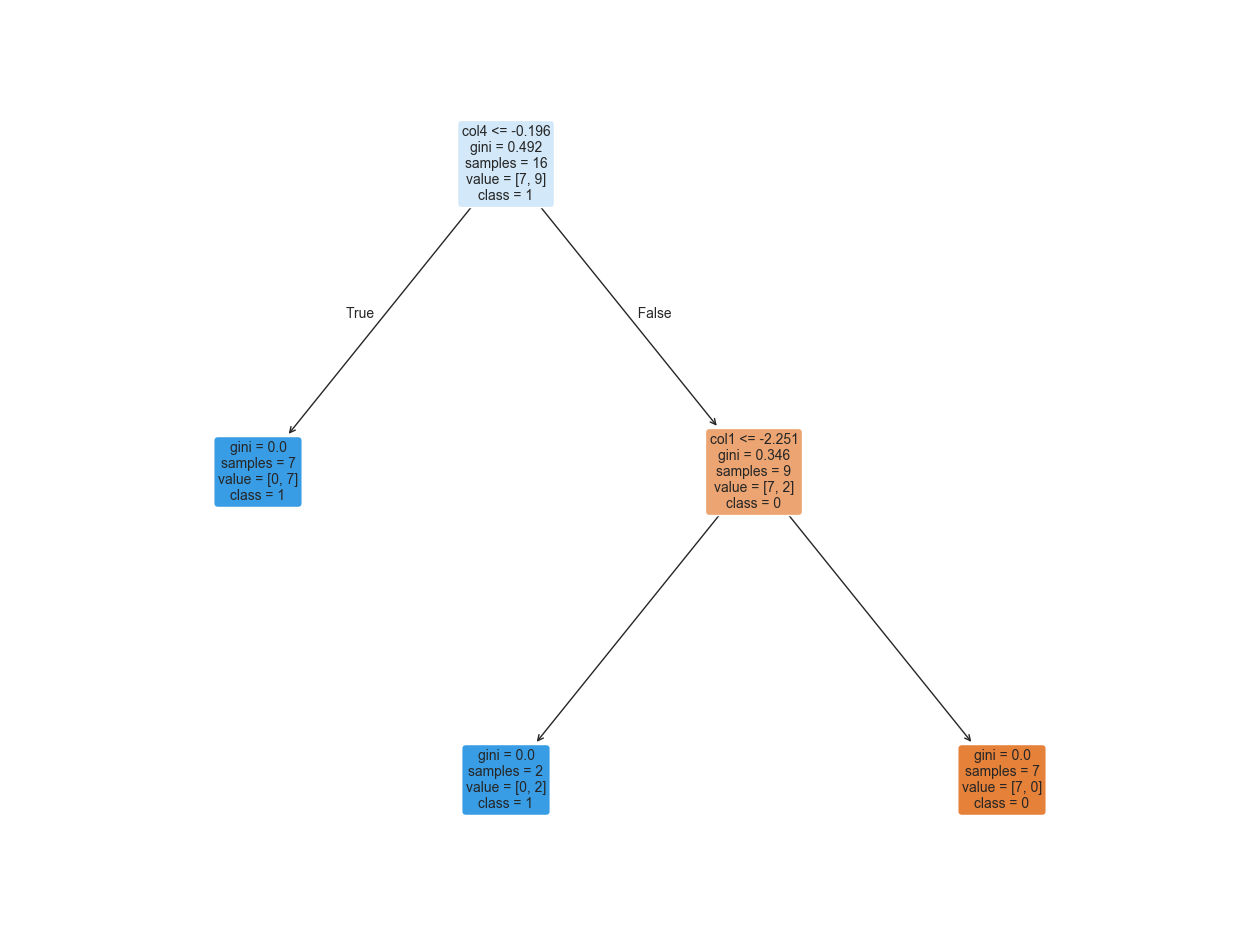

In [14]:
df_row_sample2 = row_sampling(df_train,row_sampling_ratio=0.2)

X_train2, y_train2 = split_X_y(df_row_sample2)
dt2 = plot_decision_tree(X_train2, y_train2)

#### Tree 3 

Accuracy: 0.35


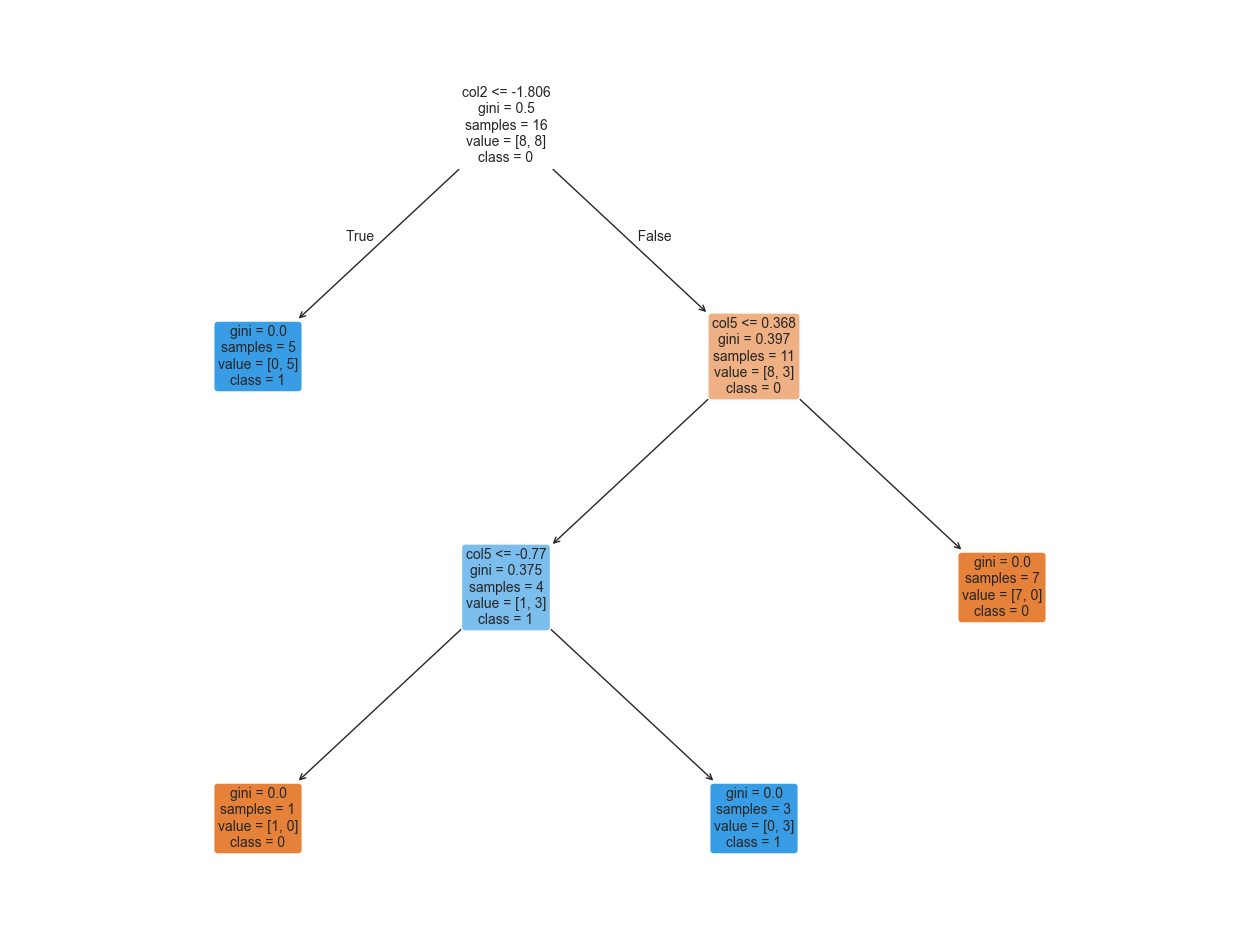

In [15]:
df_row_sample3 = row_sampling(df_train,row_sampling_ratio=0.2)

X_train3, y_train3 = split_X_y(df_row_sample3)
dt3 = plot_decision_tree(X_train3, y_train3)

In [16]:
print(dt1.predict(df_test.iloc[1,:-1].values.reshape(1,5)))
print(dt2.predict(df_test.iloc[1,:-1].values.reshape(1,5)))
print(dt3.predict(df_test.iloc[1,:-1].values.reshape(1,5)))

[0]
[0]
[0]


# 2. Col Sampling
#### Tree 1

Accuracy: 0.6


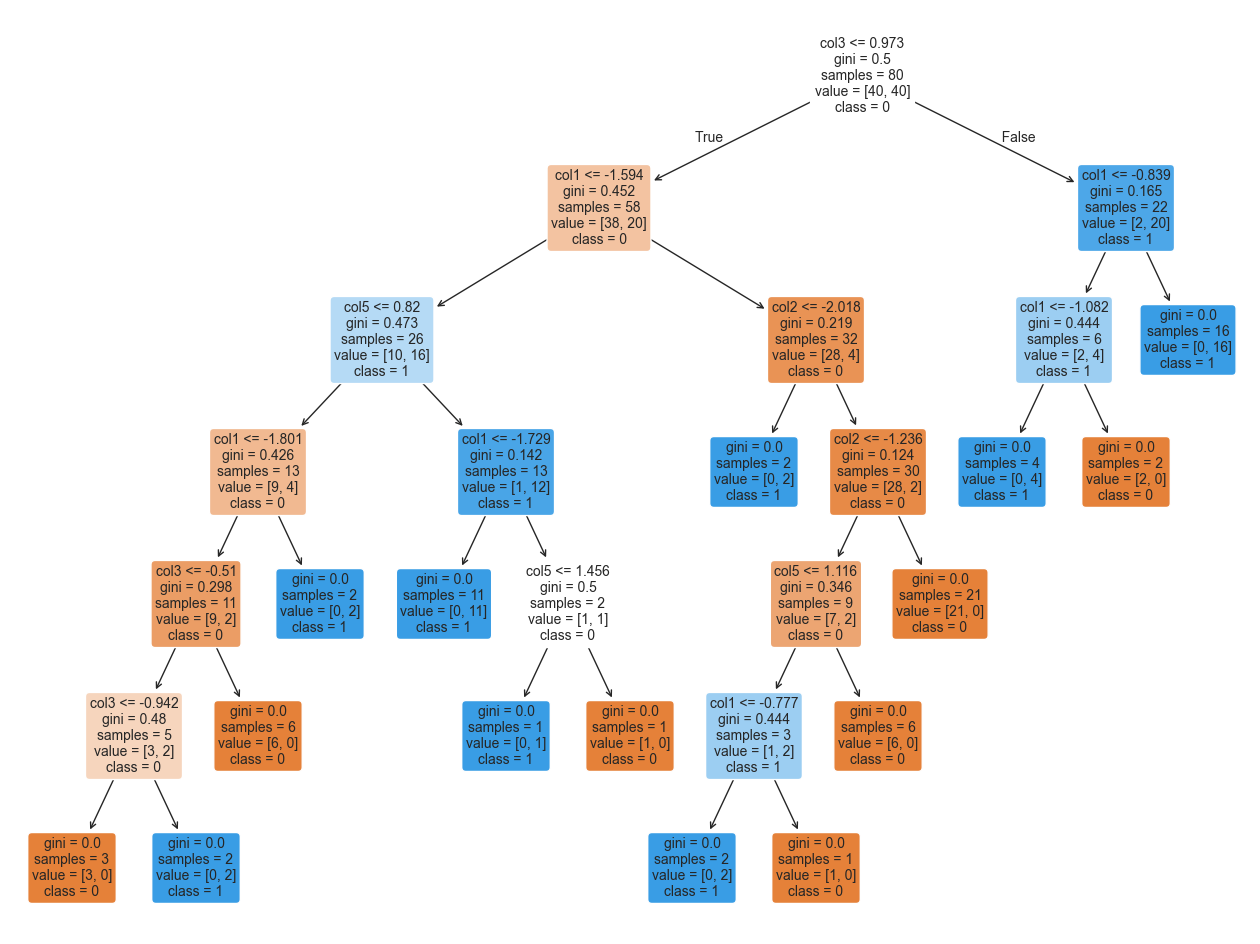

In [17]:
df_col_sample1 = col_sampling(df_train, col_sampling_ratio=0.8)

X_train1, y_train1 = split_X_y(df_col_sample1)
dt1 = plot_decision_tree(X_train1, y_train1,features_list=X_train1.columns)

#### Tree2

Accuracy: 0.5


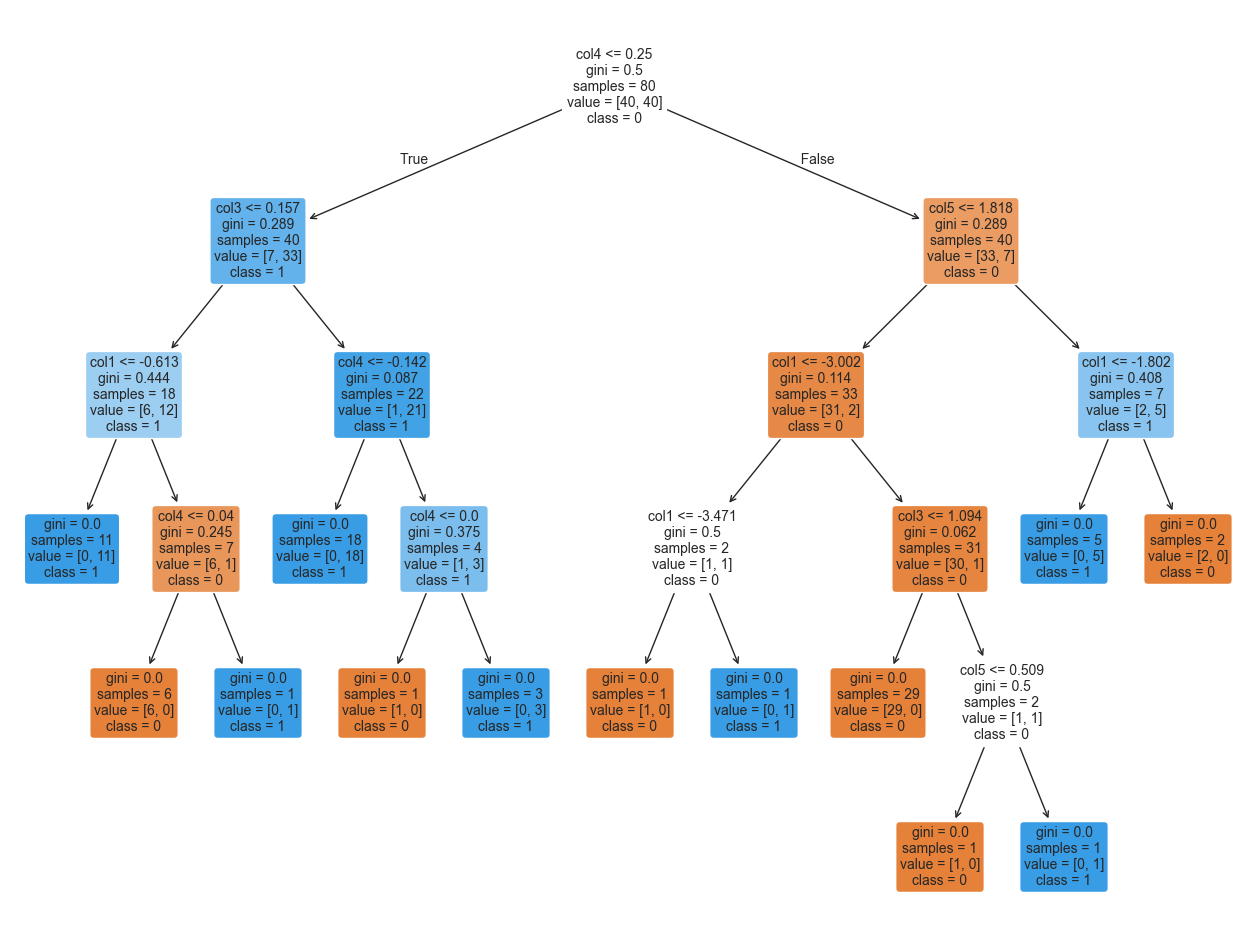

In [18]:
df_col_sample2 = col_sampling(df_train, col_sampling_ratio=0.8)

X_train2, y_train2 = split_X_y(df_col_sample2)
dt2 = plot_decision_tree(X_train2, y_train2,features_list=X_train2.columns)

#### Tree 3 

Accuracy: 0.7


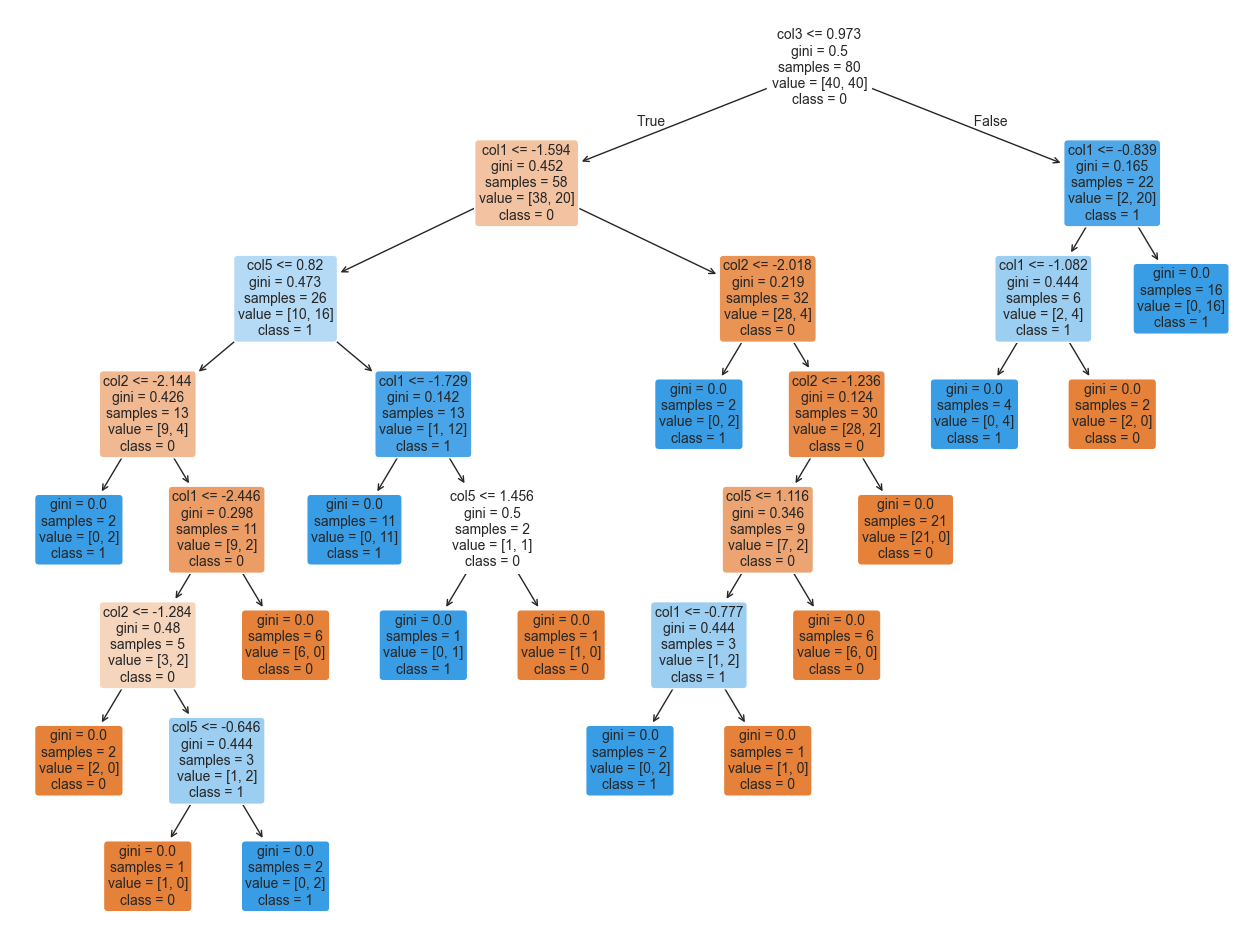

In [19]:
df_col_sample3 = col_sampling(df_train, col_sampling_ratio=0.8)

X_train3, y_train3 = split_X_y(df_col_sample3)
dt3 = plot_decision_tree(X_train3, y_train3, features_list=X_train3.columns)

In [20]:
print(dt1.predict(df_test.iloc[1, :-1][X_train1.columns].values.reshape(1, len(X_train1.columns))))
print(dt2.predict(df_test.iloc[1, :-1][X_train2.columns].values.reshape(1, len(X_train2.columns))))
print(dt3.predict(df_test.iloc[1, :-1][X_train3.columns].values.reshape(1, len(X_train3.columns))))

[0]
[0]
[0]


# 3. Row-Col Sampling
#### Tree1

Accuracy: 0.1


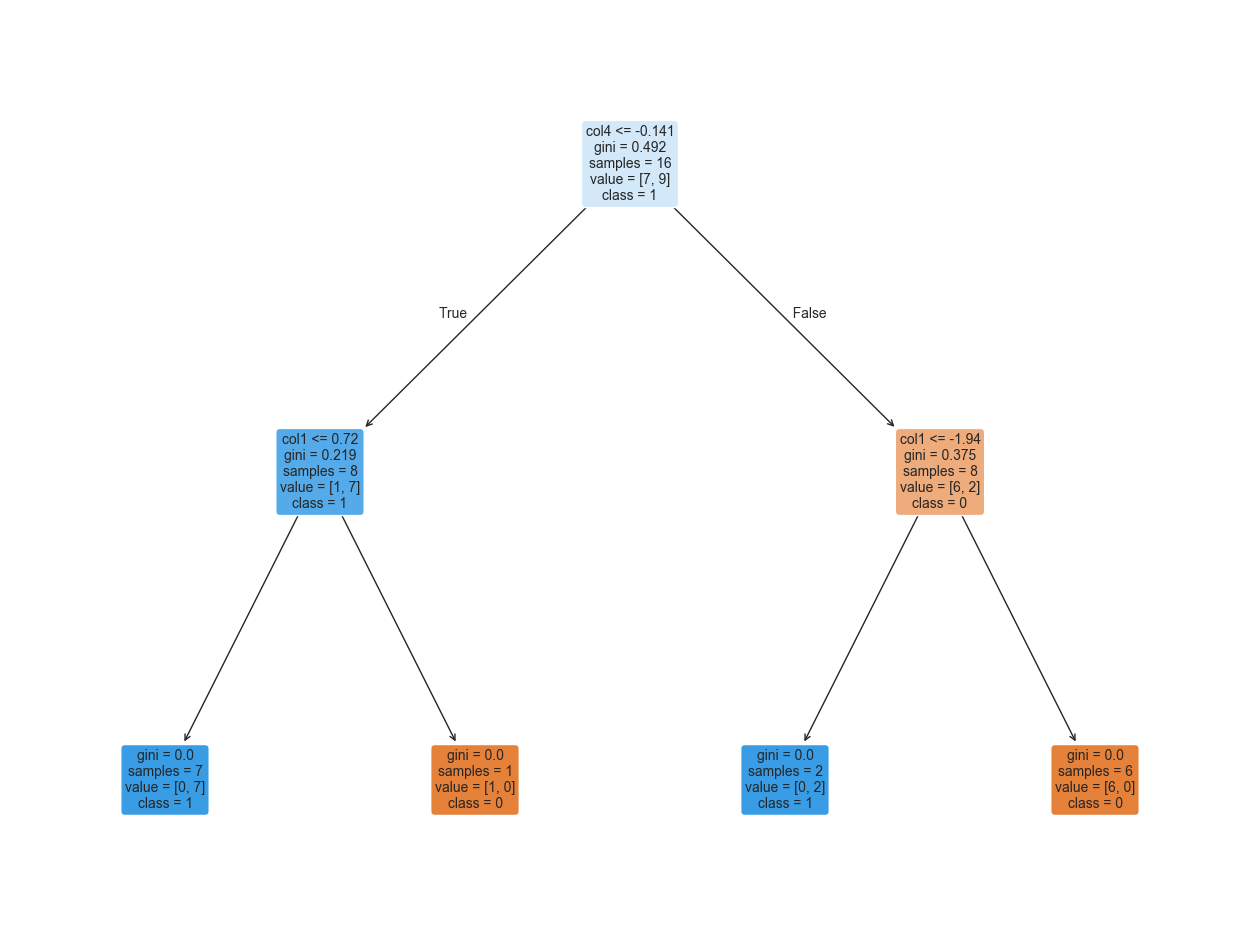

In [21]:
df_col_sample1 = combined_sampling(df_train,row_sampling_ratio=0.2, col_sampling_ratio=0.8)

X_train1, y_train1 = split_X_y(df_col_sample1)
dt1 = plot_decision_tree(X_train1, y_train1, features_list=X_train1.columns)

#### Tree2

Accuracy: 0.2


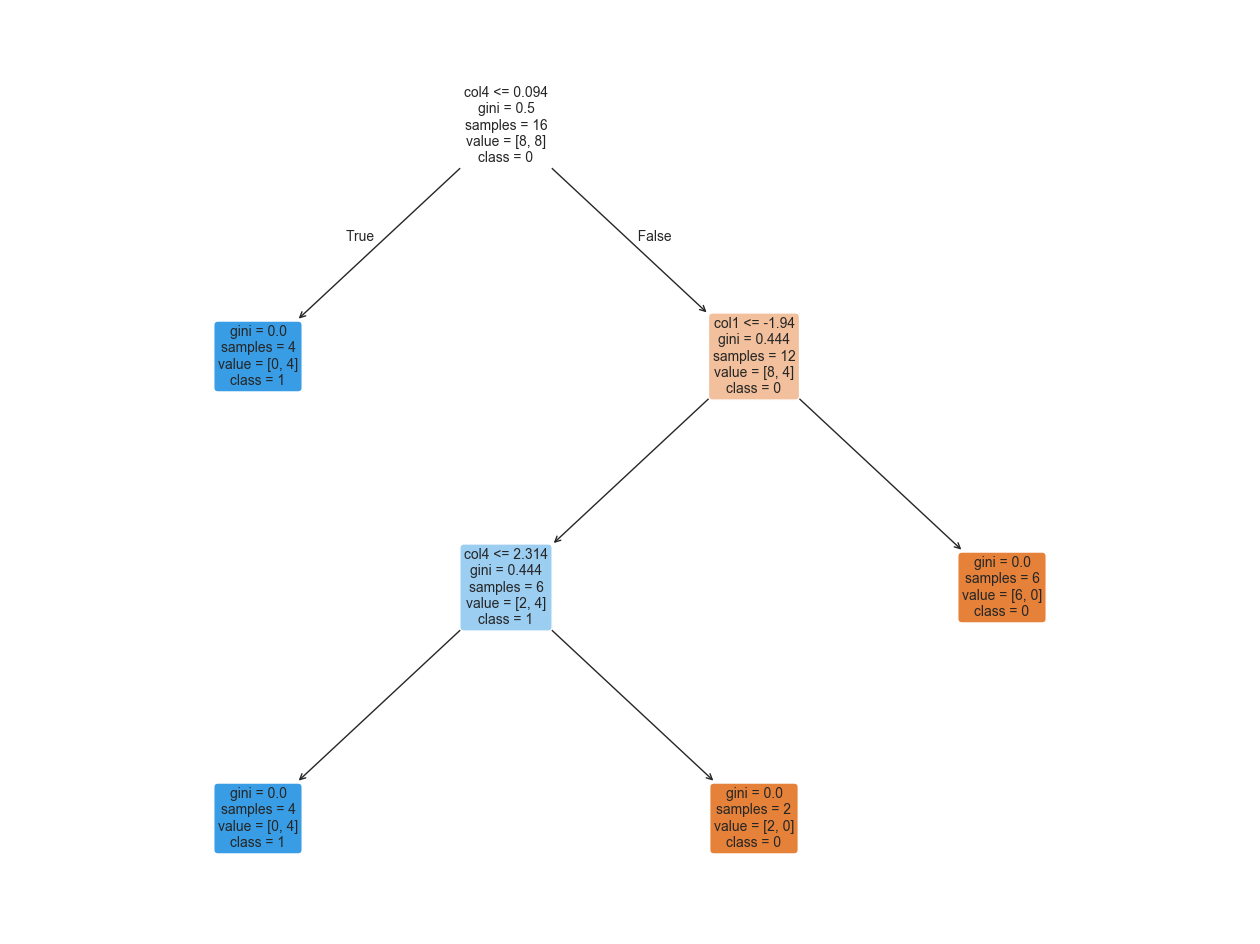

In [22]:
df_col_sample2 = combined_sampling(df_train,row_sampling_ratio=0.2, col_sampling_ratio=0.8)

X_train2, y_train2 = split_X_y(df_col_sample2)
dt2 = plot_decision_tree(X_train2, y_train2, features_list=X_train2.columns)

#### Tree 3 

Accuracy: 0.8


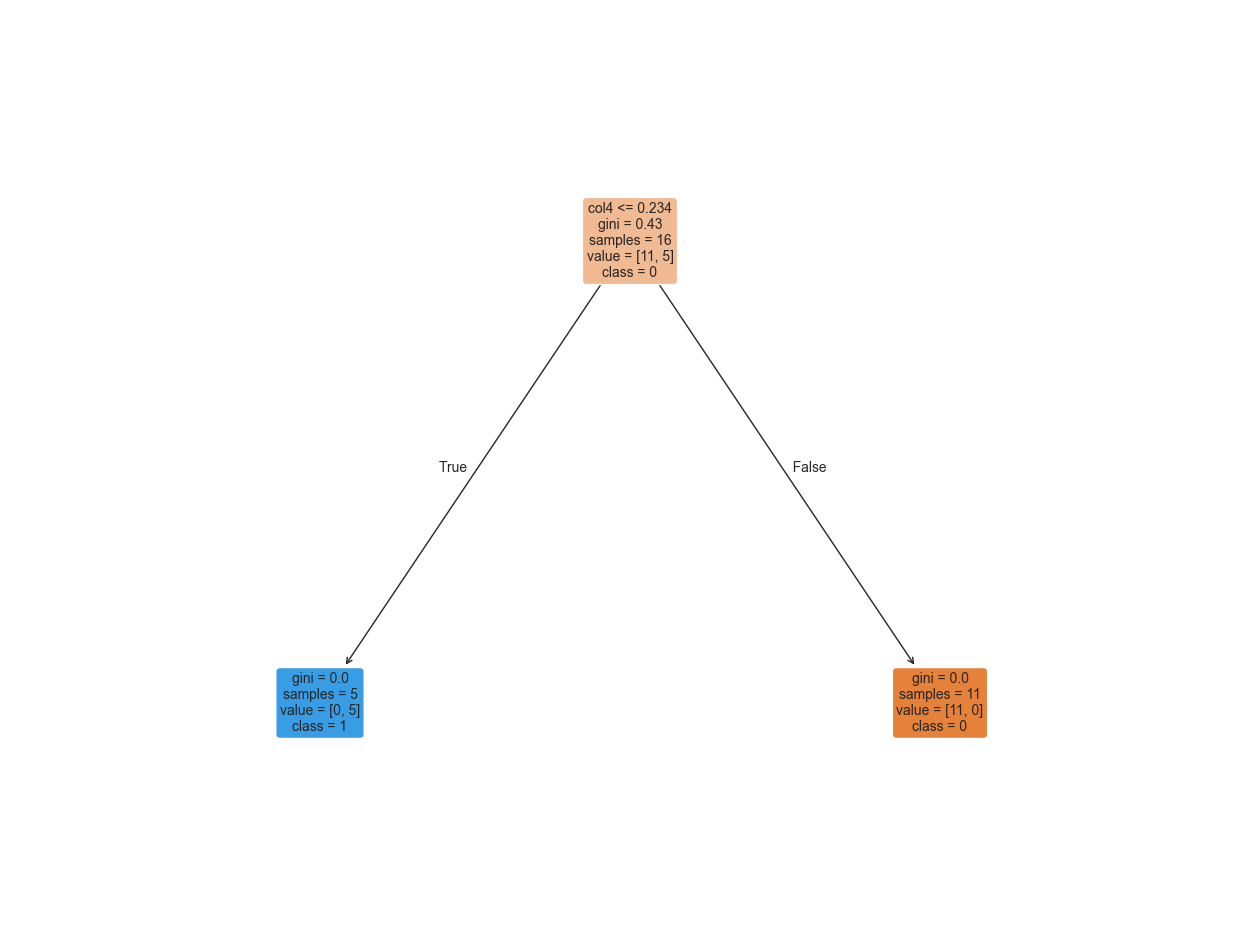

In [24]:
df_col_sample3 = combined_sampling(df_train,row_sampling_ratio=0.2, col_sampling_ratio=0.8)

X_train3, y_train3 = split_X_y(df_col_sample3)
dt3 = plot_decision_tree(X_train3, y_train3, features_list=X_train3.columns)

In [25]:
print(dt1.predict(df_test.iloc[1, :-1][X_train1.columns].values.reshape(1, len(X_train1.columns))))
print(dt2.predict(df_test.iloc[1, :-1][X_train2.columns].values.reshape(1, len(X_train2.columns))))
print(dt3.predict(df_test.iloc[1, :-1][X_train3.columns].values.reshape(1, len(X_train3.columns))))

[0]
[0]
[0]
